## Looking at plotnine with penguins data

### Importing modules

A Python module is a file containing Python code, which can include functions, classes, and variables, that can be imported and used in other Python scripts, essentially acting as a collection of reusable code to organize and structure larger programs; essentially, it's a way to group related functionalities into a single file with a ".py" extension. 

### Main Modules (Libraries) to use

To deal with data sets and preparation:
- [NumPy](https://numpy.org/doc/stable/) - to perform a wide variety of mathematical operations on numerical data documentation
- [**Pandas**](https://pandas.pydata.org/docs/) - for data structures and data analysis tools documentation

To create specific data visualizations: 
- [**seaborn**](https://seaborn.pydata.org/) - it provides a high-level interface for drawing attractive and informative statistical graphics gallery, based on matplotlib behind the scenes
- [Plotnine](https://plotnine.org/) - Plotnine is a data visualization package for Python based on the grammar of graphics
- [Altair](https://altair-viz.github.io) - Vega-Altair is a declarative visualization library for Python

In [1]:
# Common numpy and pandas import statement
import numpy as np
import pandas as pd
# Importing seaborn and matplotlib.pyplot for data viz
import seaborn as sns
# matplotlib's pyplot module, which seaborn builds upon for plotting.
import matplotlib.pyplot as plt

## 2. Import Plotnine Library 

`Turn your data into beautiful visualizations using the grammar of graphics.`

Plotnine is a data visualization package for Python based on the grammar of graphics, a coherent system for describing and building graphs. The syntax is similar to ggplot2, a widely successful R package.

For the initial explorations and examples, you may see the followings

- [Plotnine introduction guide](https://plotnine.org/guide/introduction.html)
- [Plotnine cheatsheet document](https://github.com/rstudio/cheatsheets/blob/main/plotnine.pdf)

<img src="plotnine-logo-border.png" width="300" height="1000">

## Plotnine background

One of the characteristics of the Plotnine is that, by mimicking the `ggplot2` package in R ecosystem, it allows us to create the data visualization output step by step, by adding each of the visual variable layer by layer with specific functionalities easily. The backbone of this package structure is related to book of `Grammar of Graphics` written by Leland Wilkinson in 1999. In this framework, each component of the data visualization is charaterised with specific layers that are building on each other by following the first three necessary ingridients 

`In the same way that a grammar defines the regular structures and composition of a language, his book outlines a framework to structure statistical graphics.` 

In Wickham’s adaptation of the grammar of graphics, a plot can be decomposed into three primary elements:

- the **data**, as a data frame that you are interested in 
- the **aesthetic mapping** of the variables in the data to visual cues, and mapping to specific visual channels
- the **geometry** used to encode the observations on the plot with the `geom__xx()` style functions.

### Asthetics

These are three of many different techniques for visually encoding variability. Here is a list of the aesthetic attributes that are most commonly used:

- **x:** location along the x-axis
- **y:** location along the y-axis
- **color:** hue of the mark that represents the observation
- **alpha:** the level of transparency of the color
- **size:** the size of the mark representing the observation
- **shape:** the shape of the mark representing the observation
- **fill:** the color of the inside of the representation of an observation

### Geometries

This is just a short list for the available options below, you can see [the whole list of geoms from here](https://plotnine.org/reference/#geoms)

- **`geom()`**	Base class of all Geoms
- **`geom_area()`**	Area plot
- **`geom_bar()`**	Bar plot
- **`geom_blank()`**	An empty plot
- **`geom_boxplot()`**	Box and whiskers plot
- **`geom_col()`**	Bar plot with base on the x-axis
- **`geom_count()`**	Plot overlapping points
- **`geom_density()`**	Smooth density estimate
- **`geom_dotplot()`**	Dot plot
- **`geom_histogram()`**	Histogram
- **`geom_hline()`**	Horizontal line
- **`geom_jitter()`**	Scatter plot with points jittered to reduce overplotting
- **`geom_line()`**	Connected points
- **`geom_path()`**	Connected points
- **`geom_point()`**	Plot points (Scatter plot)
- **`geom_segment()`**	Line segments
- **`geom_smooth()`**	A smoothed conditional mean
- **`geom_step()`**	Stepped connected points
- **`geom_text()`**	Textual annotations
- **`geom_violin()`**	Violin Plot
- **`geom_vline()`**	Vertical line

In [3]:
# simple install if you are doing for the first time
!pip install plotnine

  Using cached plotnine-0.13.6-py3-none-any.whl (1.3 MB)
  Using cached mizani-0.11.4-py3-none-any.whl (127 kB)


In [4]:
import plotnine
# Or some specific parts of the module
#from plotnine import ggplot, aes, geom_point, labs

# Import penguins data
from plotnine.data import penguins

In [5]:
# To check whether which version we got and is it properly imported
print(plotnine.__version__)

0.13.6


## Penguins Data to explore

Data about 3 different species of penguins collected from 3 islands in the Palmer Archipelago, Antarctica. Like Cara's example on a story of data visualization, we may play around this data set immediately
 
- Data comes from the seaborn package for data viz examples so it is possible to use previously published data sets from python modules (libraries)

- The details of the data can be checked for further illustrations similar to the above examples 

<img src="palmerpenguins.png" width="400" height="2000">

The penguin dataset is a dataframe with 344 rows and 8 variables

Numerical columns are:

- **bill_length_mm** (quantitative) 
- **bill_depth_mm** (quantitative) 
- **flipper_length_mm** (quantitative) 
- **body_mass_g** (quantitative)
- **year** (timestamps) - the year of the data collection, not add a real value to the other variables

Categorical columns are:

- **species** (Adelie/Gentoo/Chinstrap) - the different species we have
- **island** (Biscoe/Dream/Torgersen) - whether or not the person who paid the bill is a smoker
- **sex** (Male/Female) - the gender of penguins, there are some unknown cases as missing

In [6]:
# Check the data description
df_penguin = penguins

# Just to check how data looks like 
print(df_penguin.head(10))

# General look at the data attributes 
print(df_penguin.info())
# Look at main summary statistics quickly
print(df_penguin.describe())

# Checking the columns having some missing, if any
print(df_penguin.isnull().any())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   
6  Adelie  Torgersen            38.9           17.8              181.0   
7  Adelie  Torgersen            39.2           19.6              195.0   
8  Adelie  Torgersen            34.1           18.1              193.0   
9  Adelie  Torgersen            42.0           20.2              190.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  

In [10]:
## Finding the frequency of species to illustrate
df_penguin[["species"]].value_counts(dropna=False)

species  
Adelie       152
Gentoo       124
Chinstrap     68
dtype: int64

In [11]:
## Finding the frequency of species to illustrate
df_penguin[["island"]].value_counts(dropna=False)

island   
Biscoe       168
Dream        124
Torgersen     52
dtype: int64

In [67]:
# Some additional statistics details can be added 
print(df_penguin.median(axis=0))
print(df_penguin.var(axis=0))

bill_length_mm         44.45
bill_depth_mm          17.30
flipper_length_mm     197.00
body_mass_g          4050.00
year                 2008.00
dtype: float64
bill_length_mm           29.807054
bill_depth_mm             3.899808
flipper_length_mm       197.731792
body_mass_g          643131.077327
year                      0.669706
dtype: float64


/tmp/ipykernel_134/144812953.py:2: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
/tmp/ipykernel_134/144812953.py:3: FutureWarning: The default value of numeric_only in DataFrame.var is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.


### Essential pandas for Data Exploration and Preparation

- Checking and removing duplicates if we have any
- Data aggregation and grouping techniques using groupby.
- Handle missing data appropriately with suitable functions like `fillna` and `dropna`.
- Indexing the data to reach out necessary components, when we needed 


For some other functions, this list might be useful also [Pandas DataFrame operations](https://pandas.pydata.org/docs/reference/frame.html)

**Checkd and Remove Duplicates**

Duplicate data can be a serious issue, luckily pandas offers a simple way to remove duplicates

In [12]:
# Simple demonstration
df_penguin.drop_duplicates(subset=None, keep='first', inplace=False, ignore_index=False)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [25]:
# Original shape of tips data
print(df_penguin.shape)
# Shape of the data after dropping the duplicate
print(df_penguin.drop_duplicates().shape)

(344, 8)
(344, 8)


#### 1. Grouping Data with groupby

Enables efficient computation of summary statistics for subsets of data. Facilitates complex analyses by splitting data into meaningful groups.

Cons:
- Can lead to performance issues with very large datasets if not used judiciously.
- The resulting grouped object requires further operations to extract meaningful information.

In [13]:
# Simple summary statistics again 
df_penguin.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [14]:
# Grouping data by a categorical variable and calculating the mean
grouped_data = df_penguin.groupby('species').mean()
print(grouped_data)

# Resetting index to flatten the DataFrame
grouped_data = grouped_data.reset_index()
# Displaying the grouped data
print(grouped_data)

           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
species                                                                    
Adelie          38.791391      18.346358         189.953642  3700.662252   
Chinstrap       48.833824      18.420588         195.823529  3733.088235   
Gentoo          47.504878      14.982114         217.186992  5076.016260   

                  year  
species                 
Adelie     2008.013158  
Chinstrap  2007.970588  
Gentoo     2008.080645  
     species  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0     Adelie       38.791391      18.346358         189.953642  3700.662252   
1  Chinstrap       48.833824      18.420588         195.823529  3733.088235   
2     Gentoo       47.504878      14.982114         217.186992  5076.016260   

          year  
0  2008.013158  
1  2007.970588  
2  2008.080645  


/tmp/ipykernel_134/479745282.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


#### 2. Handling Missing Data with fillna and dropna

Missing data occurs commonly in many data analysis applications. In pandas, missing numeric data is represented by `NaN` (Not a Number) and can easily be handled by certain functions; 

- `dropna` provides a straightforward method to remove missing data, which can simplify analysis.
- `fillna` allows for imputation of missing values, maintaining the DataFrame's structure.


Cons:

- Imputation may introduce bias if not done carefully.
- Dropping missing data can lead to loss of valuable information, especially in small datasets.

In [15]:
df_penguin_copy = df_penguin.copy()

# Checking for missing values using isnull()
missing_values = df_penguin_copy.isnull()
print(missing_values.sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [16]:
# Dropping rows with any missing values

# Using with additional 'how' argument below: 
# 'any' : If any NA values are present, drop that row or column.
# 'all' : If all values are NA, drop that row or column.
df_penguin_copy_cleaned = df_penguin_copy.dropna(how = 'any')

# Displaying the DataFrame shape after dropping missing values
print("DataFrame shape after dropping missing values:", df_penguin_copy_cleaned.shape)
print(df_penguin_copy_cleaned.isnull().sum())

DataFrame shape after dropping missing values: (333, 8)
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64


Here are some other methods for working with `NaN` which you can find useful:
    
| Method | Description |
| -- | -- |
| dropna | Filter axis labels based on whether the values of each label have missing data|
| fillna | Fill in missing data with some value |
| isnull | Return boolean values indicating which values are missing |
| notnull | Negation of isnull |

**Caution: *Filling the missing values might be a challenging task for you during the group project, if you face with*. The necessary tools are mainly the beyond the scope of that course so it is better to stick to the complete data (remaining data after removing the missing values)** if the dropping missing values do not lead losing too many observations!

# Visualization with Plotnine

In this tutorial you will see how to visualise your data using plotnine. Python has many packages for making graphs, but plotnine can be one of the most elegant and most versatile. As we said earlier one, plotnine implements the grammar of graphics, a coherent system for describing and building graphs. Simply we have three main layers (components), or necessary ingridients to start with

- **data frame**, as the first layer
- **coordinate system**, as the second one, where we start defining our aesthetics via `aes()`
- **geoms**, as the third one, that are visual marks that represent data points and allows different type of visualizations

![Plotnine](Plotnine_Main3layers.png)


<img src="grammar-of-graphics.png" width="500" height="2000">

**REMARK: Good to remember the [From Data to Viz website](https://www.data-to-viz.com/) again for explorations to match the type of data with the type of charts by looking at the [examples gallery from plotnine](https://plotnine.org/gallery/)**

For initial exploration, let us look at the main layers to work on penguins data set 

In [7]:
# Loading some necessary module components if you do this one by one
# from plotnine import ggplot, aes, geom_histogram, labs

# More common usage to load all library functionalities
from plotnine import *

In [16]:
# Create a visualization to start with


## Different Types of visualizations

### displot - Understanding the distributional behaviour of univariate numeric variable

- Let's start with a distributional plot (which shows how values are distributed), for example a histogram
- We usually need to specify the dataset and the variable on X axis (maybe the variable on Y axis too). 
- Then you can set the type of the plot to be some suitable `geom_xxx()` layer. 
- You can control the number of distinguished bars in a histogram with `bins=-` and make the histogram more/less smooth.


/opt/conda/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight


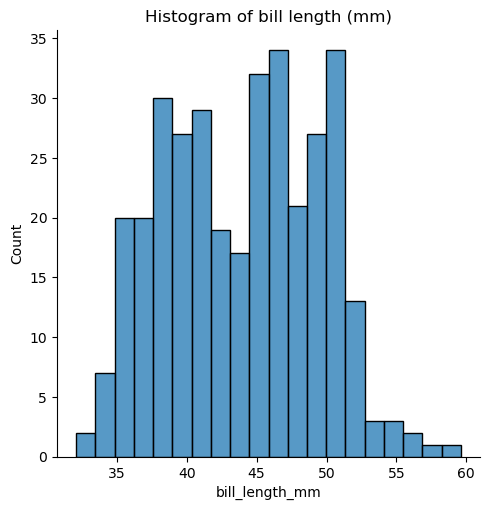

/opt/conda/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight


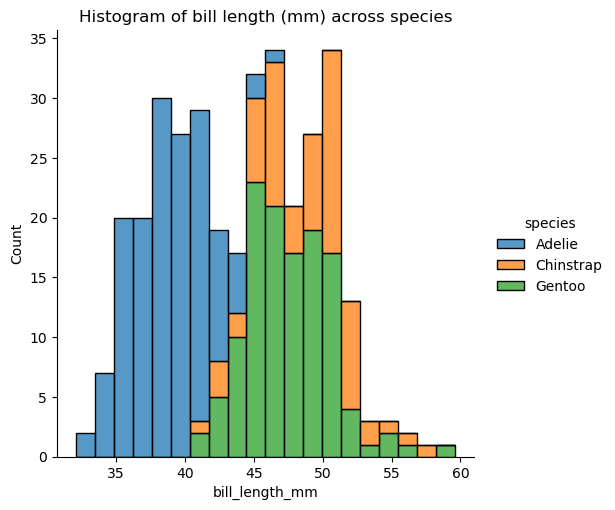

In [10]:
# EARLIER on WITH SEABORN
sns.displot(data=df_penguin, x="bill_length_mm", bins=20)
# sns.histplot(data=df_penguin, x="bill_length_mm", bins=20)
# plot's title
plt.title('Histogram of bill length (mm)')
# Seaborn is built on top of Matplotlib, so we can use plt.show() to display the plot
plt.show()

# Creating a multiple histograms on same figure with extra input arguments
sns.displot(data=df_penguin, x="bill_length_mm", kind="hist", bins=20,
            hue = 'species', multiple = 'stack')

# plot's title
plt.title('Histogram of bill length (mm) across species')
# To display the plot clearly
plt.show()

/opt/conda/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 2 rows containing non-finite values.


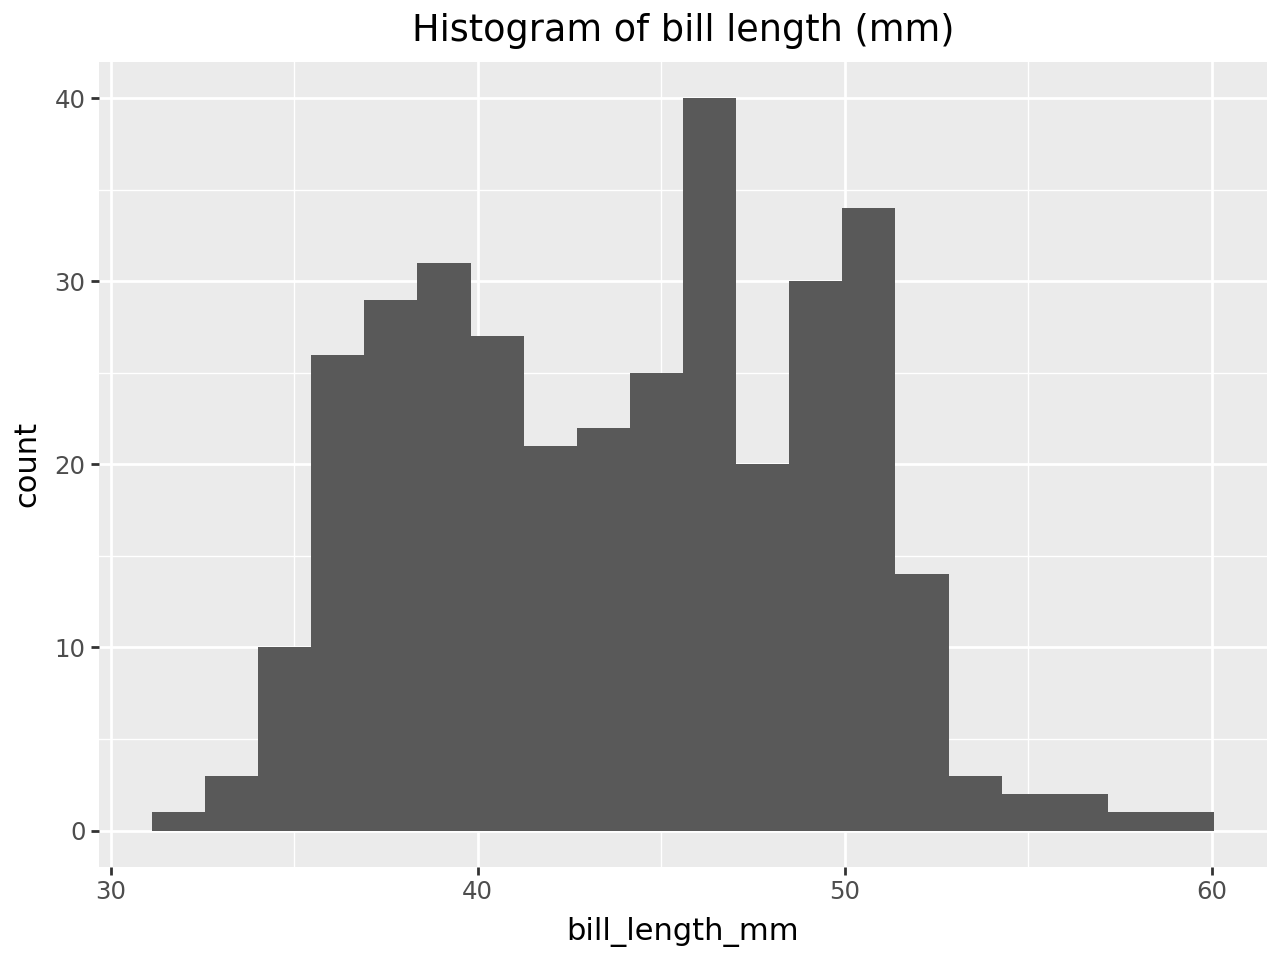

In [8]:
# NOW DOING WITH Plotnine in a different syntax

( # add necessary three layers first and think about other extras as optional later
    ggplot(df_penguin, aes(x = "bill_length_mm"))
    + geom_histogram(bins = 20)
    + labs(title = 'Histogram of bill length (mm)') # Labelling quickly with labs()
)


/opt/conda/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 2 rows containing non-finite values.


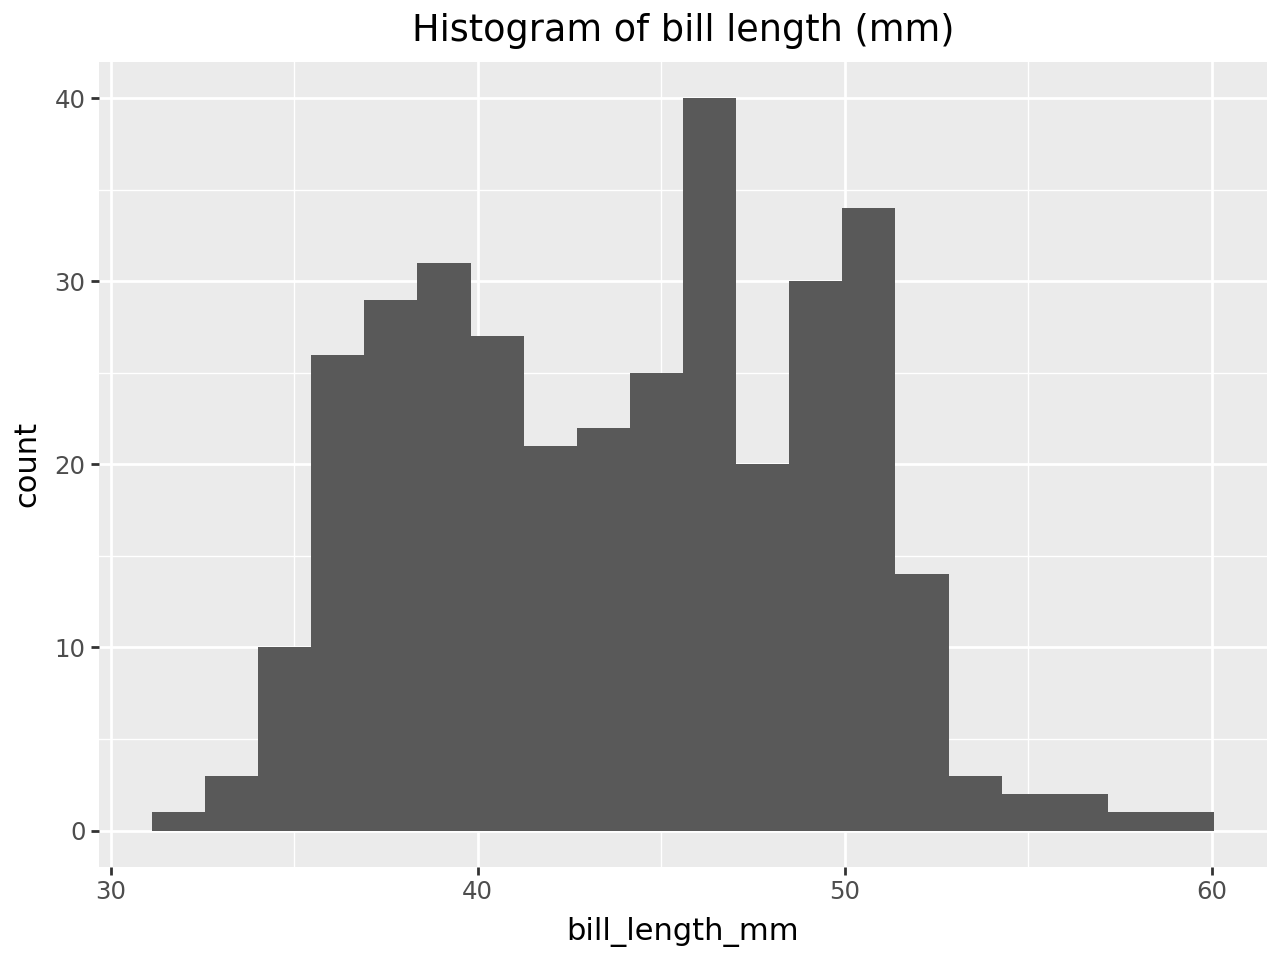

In [9]:
# This layering works also!

( # add necessary three layers first and think about other extras as optional later
    ggplot(df_penguin)
    + aes(x = "bill_length_mm")
    + geom_histogram(bins = 20)
    + labs(title = 'Histogram of bill length (mm)') # Labelling quickly with labs()
)

/opt/conda/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 2 rows containing non-finite values.


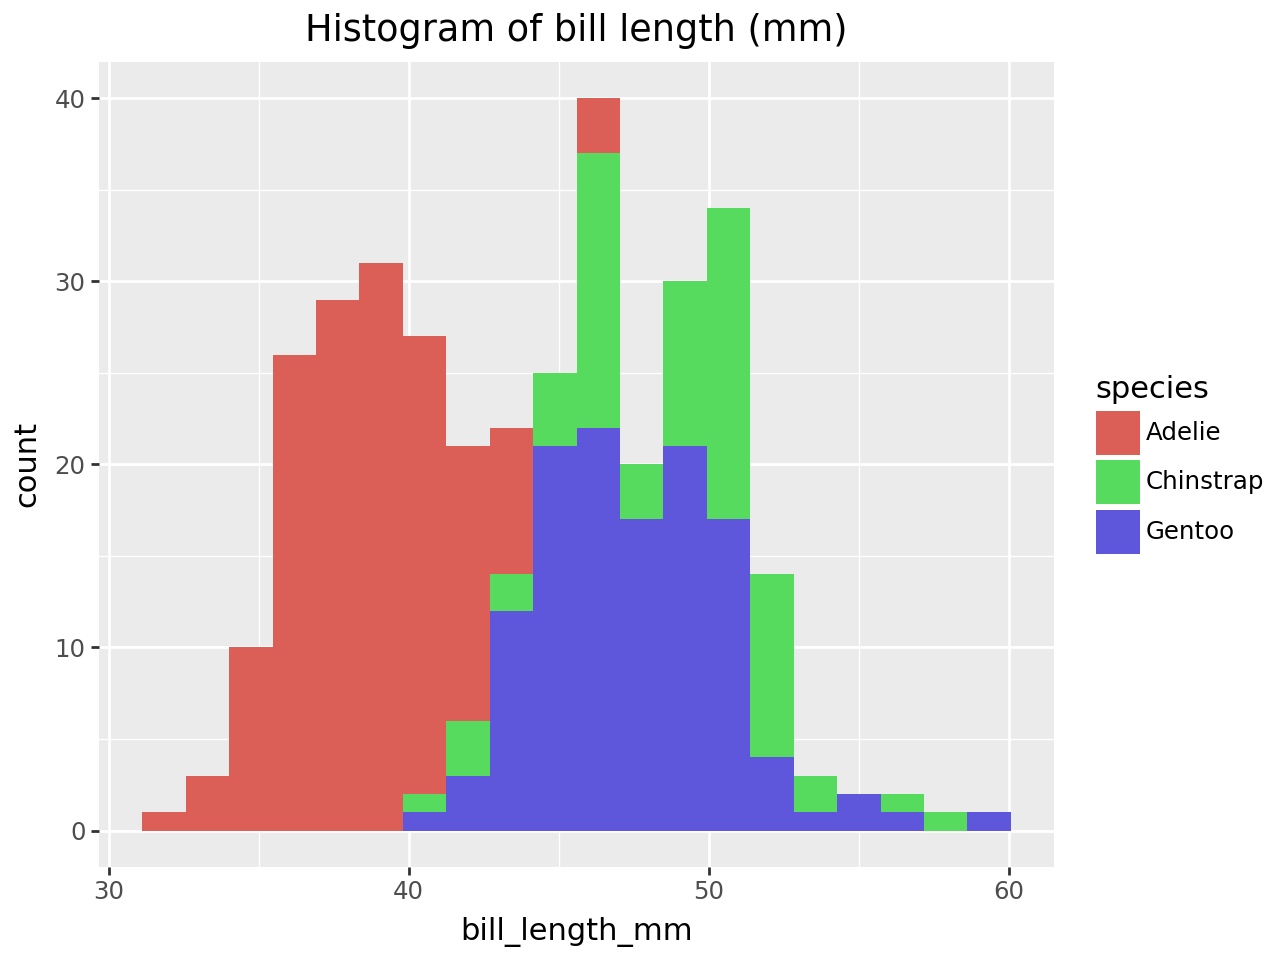

In [31]:
# NOW DOING WITH Plotnine in a different syntax

( # add necessary three layers first and think about other extras as optional later
    ggplot(df_penguin)
    + aes(x = "bill_length_mm", fill="species")
    + geom_histogram(bins = 20)
    + labs(title = 'Histogram of bill length (mm)')
)


---

**Try followings and reflect on**

- what about changing the parameter `bins` instead of 20, try smaller (5) or larger values (50) ?
- what if you add the input argument `position="stack"` inside of `geom_histogram()` and create the visualization again ?
- what about using another categorical variable for `color` such as island ?

---

### How to visualize the main necessary steps on plotnine

Let us look at the certain components in a visual diagram to see how that works 

<img src="plotnine_visual_steps.png" width="600" height="2000">

### Scatterplot - Understanding the relationship between two numerical variables

- A scatter plot displays the relationship between two numerical variables. 

- In this example, we'll examine the relationship between the total bill amount and the tip amount.

[Explore the other parameters](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) such as `hue="smoker"`, `size="size"`, `linewidth=0` ...

/opt/conda/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight


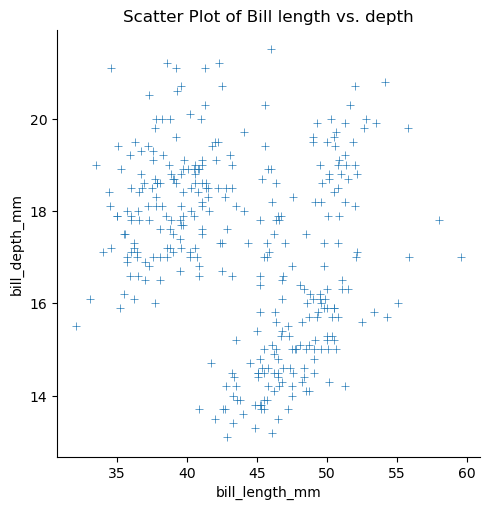

In [97]:
# EARLIER on WITH SEABORN

# Create a scatter plot
sns.relplot(data=df_penguin, x='bill_length_mm', y='bill_depth_mm', marker= '+')
#sns.scatterplot(data=df_penguin, x='bill_length_mm', y='bill_depth_mm', marker='+')

# Add a title
plt.title('Scatter Plot of Bill length vs. depth')

# To display the plot clearly
plt.show()

### Facetting into multiple plots easily

Faceting is a way to subset data and plot it on different panels. This allows us to breakdown a visual into subsets easily, on the values of one or more discrete values. Two useful functions to explore 

- `facet_grid()`, is used to form a grid of plots, where the rows and columns of the grid are set by the faceting variables. It is useful for visualising two discrete variables. 
- `facet_wrap()`, creates a collection of plots (facets), where each plot is differentiated by the faceting variable. These plots are wrapped into a certain number of columns or rows as specified by the user.

/opt/conda/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


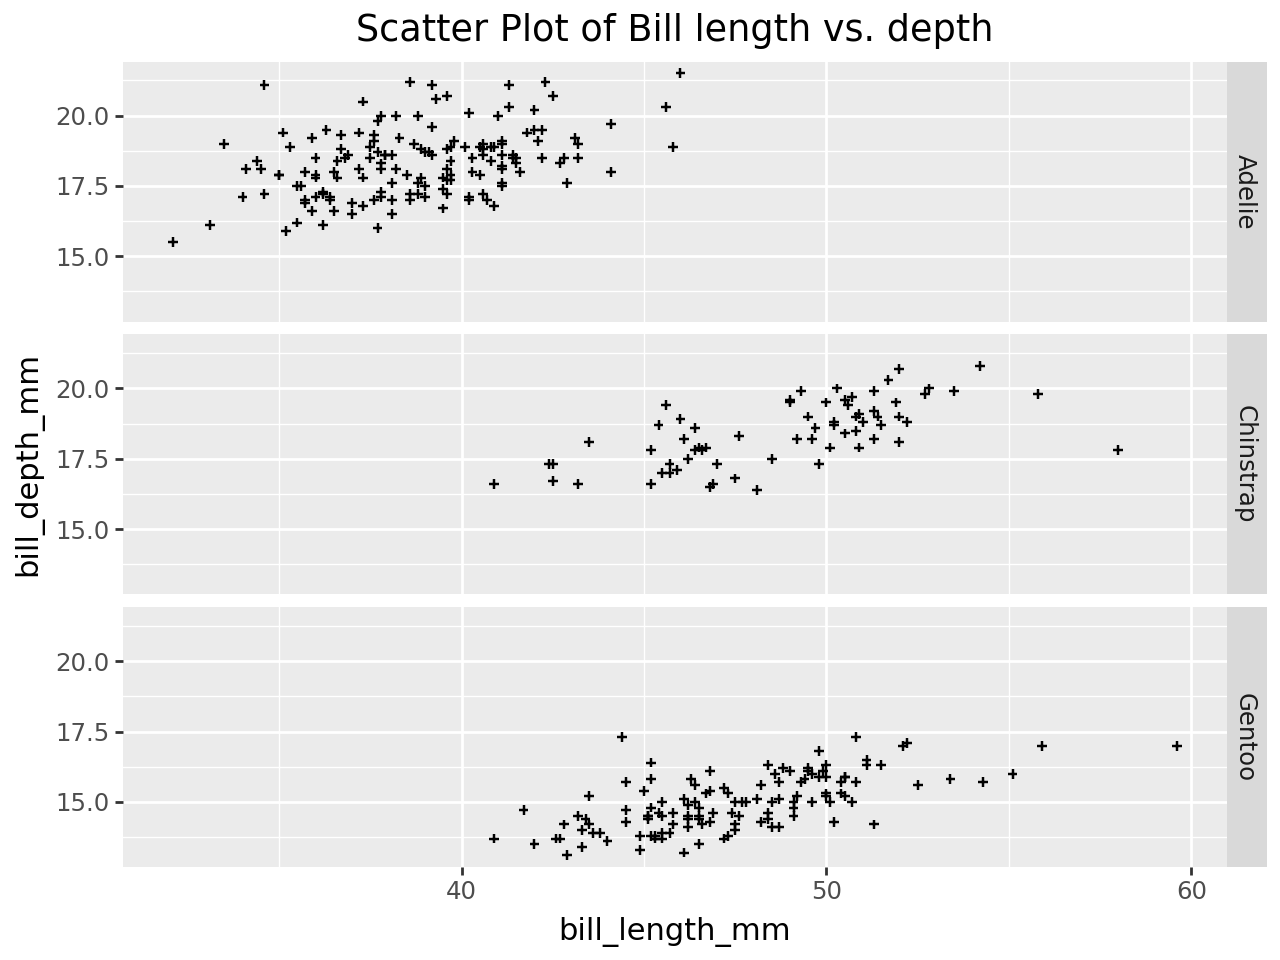

In [37]:
# NOW DOING WITH Plotnine in a different syntax

( # add necessary three layers first and think about other extras as optional later
    ggplot(df_penguin, aes(x = "bill_length_mm", y='bill_depth_mm'))
    + geom_point(shape = '+')
    + facet_grid('species')
    + labs(title = 'Scatter Plot of Bill length vs. depth')
)

---

**Try followings and reflect on**

- what about adding the `fill="species"` to your list of inputs in `aes()` again ? or color="species"
- what do you get when you add the new line of code as `facet_wrap('species')` ? or `facet_grid('species')`
- how to change output figure panel style by additional input arguments within the `facet_grid()` function ? Check out the [related documentation](https://plotnine.org/reference/facet_grid.html#plotnine.facet_grid)

---

### barplot - Understanding the frequency of a categorical variable

- Bar plots are suitable for visualizing categorical data with corresponding numerical values. 

- Here, we'll compare the average total bill amount for each day of the week.

[Explore the other parameters](https://seaborn.pydata.org/generated/seaborn.barplot.html) such as; `errorbar=None`, `estimator=sum` , `hue = 'sex'`

/opt/conda/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight


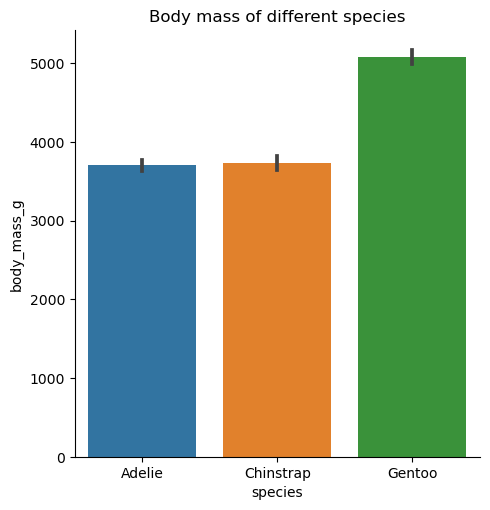

In [38]:
# EARLIER on WITH SEABORN

# Create a bar plot
sns.catplot(data=df_penguin, x='species', y="body_mass_g", kind="bar") # Add this hue="sex"

# Add a title
plt.title('Body mass of different species')

# To display the plot clearly
plt.show()

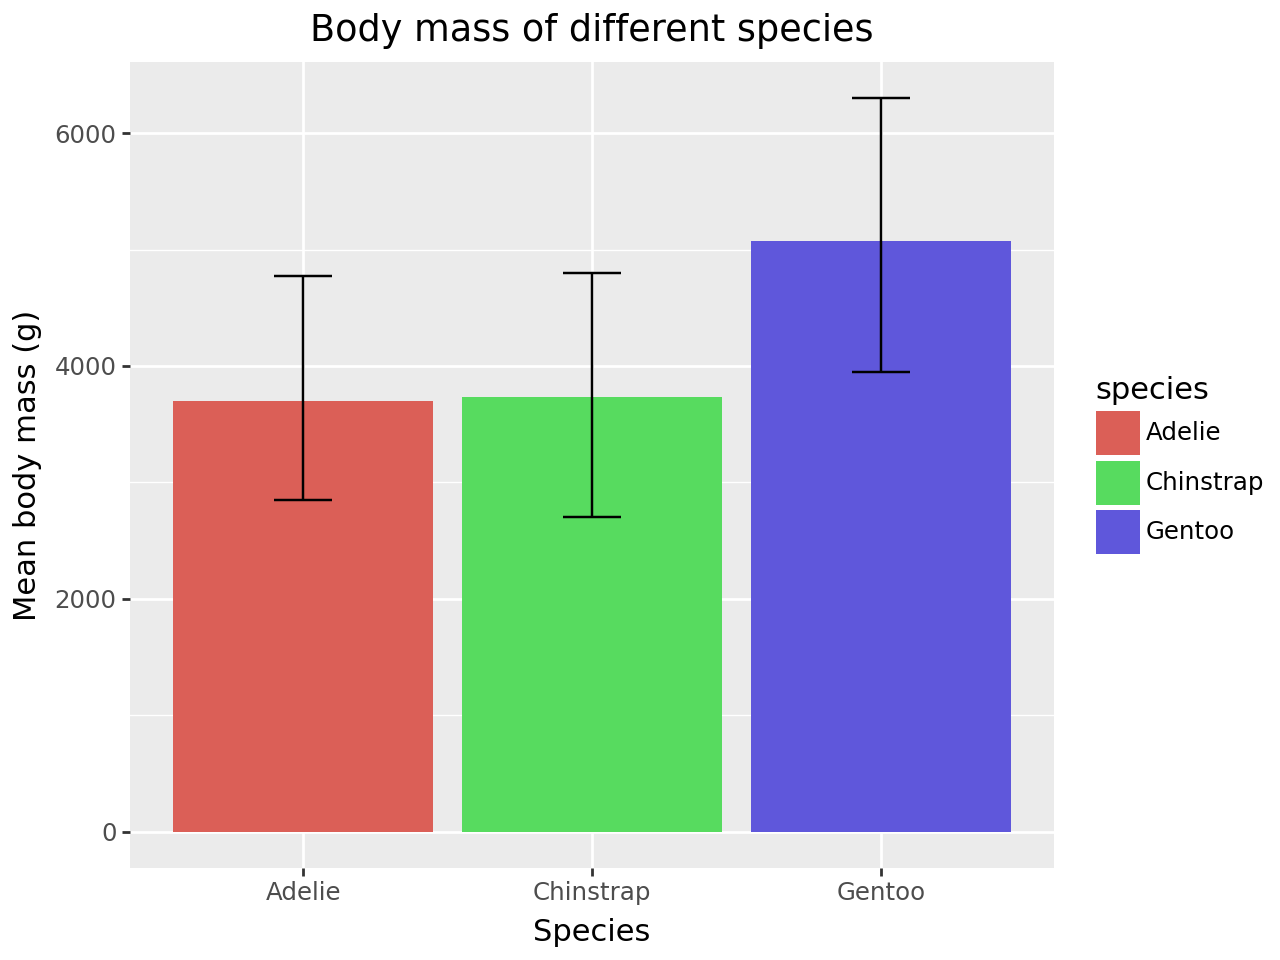

In [39]:
# NOW DOING WITH Plotnine in a different syntax

df_penguin = penguins.dropna(subset=["body_mass_g", "species"])

# In plotnine, errorbar limits usually come from mapped aesthetics or from a summary stat.
summary = (df_penguin
           .groupby("species", as_index=False)
           .agg(mean_mass=("body_mass_g", "mean"),
                min_mass=("body_mass_g", "min"),
                max_mass=("body_mass_g", "max")))

(
    ggplot(summary, aes(x="species", y="mean_mass", fill="species"))
    + geom_col()
    + geom_errorbar(aes(ymin="min_mass", ymax="max_mass"), width=0.2)
    + labs(title="Body mass of different species", y="Mean body mass (g)", x="Species")
)

/opt/conda/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight


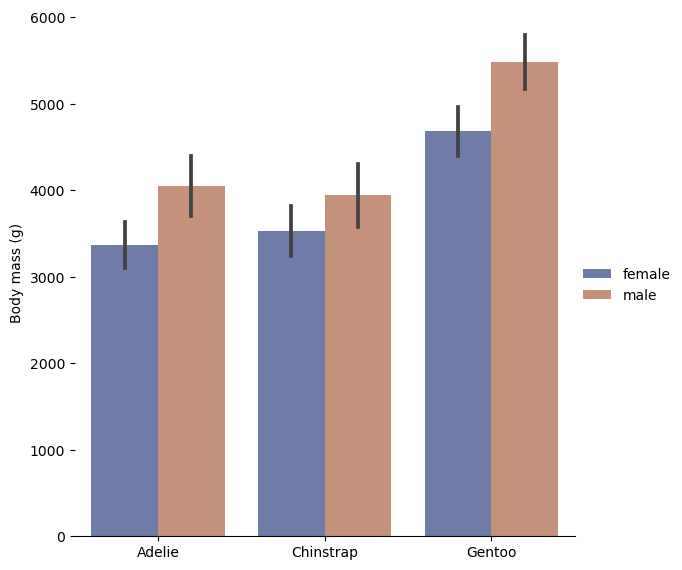

In [43]:
# EARLIER on WITH SEABORN

# Draw a nested barplot by species and sex
g = sns.catplot(data=df_penguin, kind="bar", x="species", y="body_mass_g", hue="sex",
    errorbar="sd", palette="dark", alpha=.6, height=6)
g.despine(left=True)
g.set_axis_labels("", "Body mass (g)")
g.legend.set_title("")
plt.show(g)

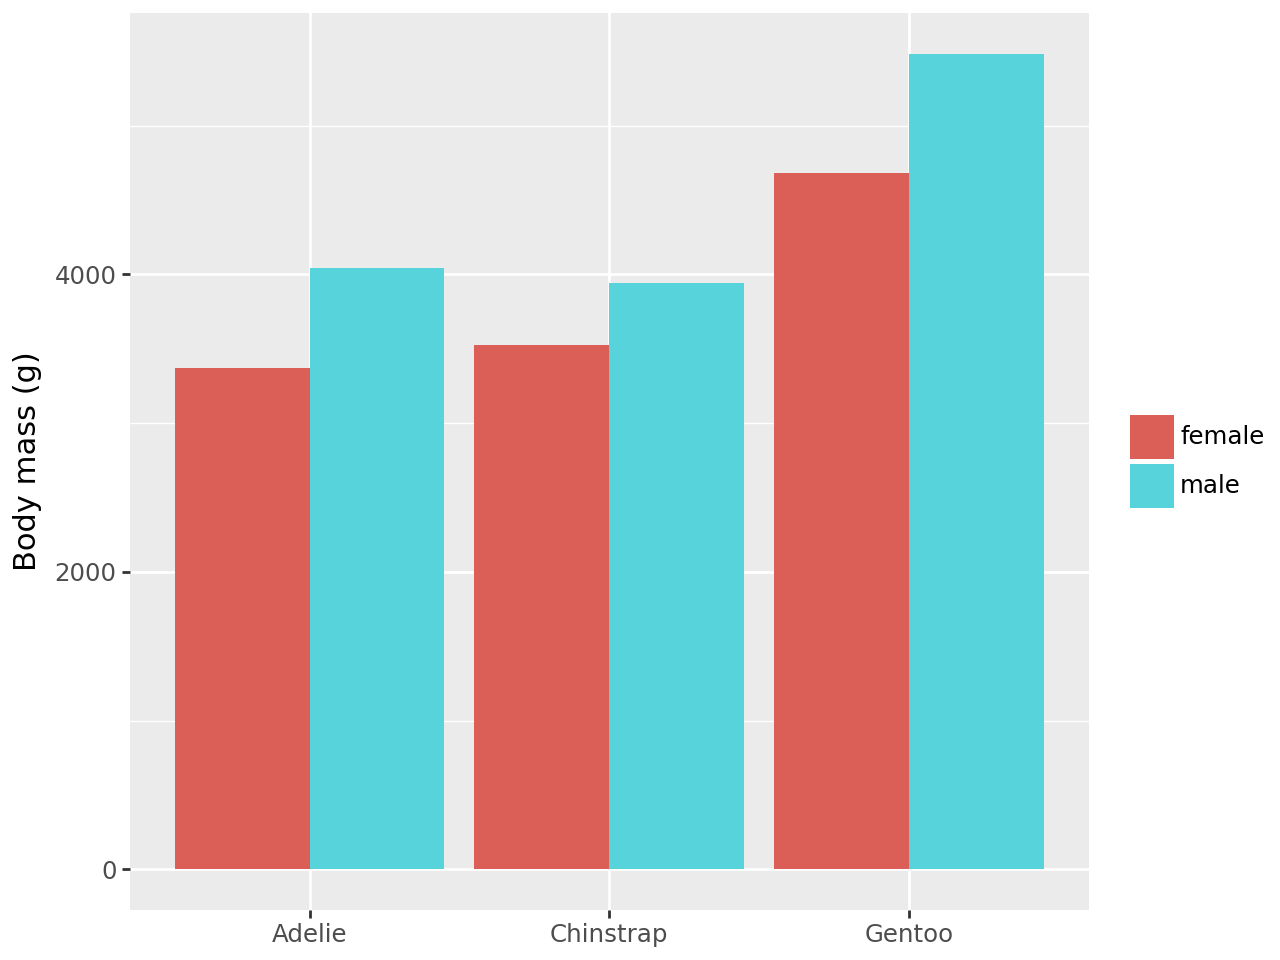

In [44]:
# NOW DOING WITH Plotnine in a different syntax

# import the plotnine pieces we’ll use
from plotnine import ggplot, aes, stat_summary, position_dodge, labs, theme, element_blank  

 # remove rows with missing values in the variables we plot
df_penguin = penguins.dropna(subset=["body_mass_g", "species", "sex"]) 

(
    ggplot(df_penguin, aes("species", "body_mass_g", fill="sex"))  # start a plot: x=species (categories), y=body_mass_g, color/fill bars by sex
    + stat_summary(  # compute summary statistics per (species, sex) group and draw a geometry
        geom="col",  # draw bars (columns)
        fun_y=np.mean,  # bar height = mean body mass in each group
        position=position_dodge(),  # place sex groups side-by-side within each species (dodged bars)
        #alpha=0.6  # make the bars slightly transparent (like seaborn's alpha=.6)
    )
    + labs(x="", y="Body mass (g)", fill="")  # axis/legend labels: blank x label, y label text, and remove legend title
    + theme(legend_title=element_blank())  # also ensure the legend title is blank
)

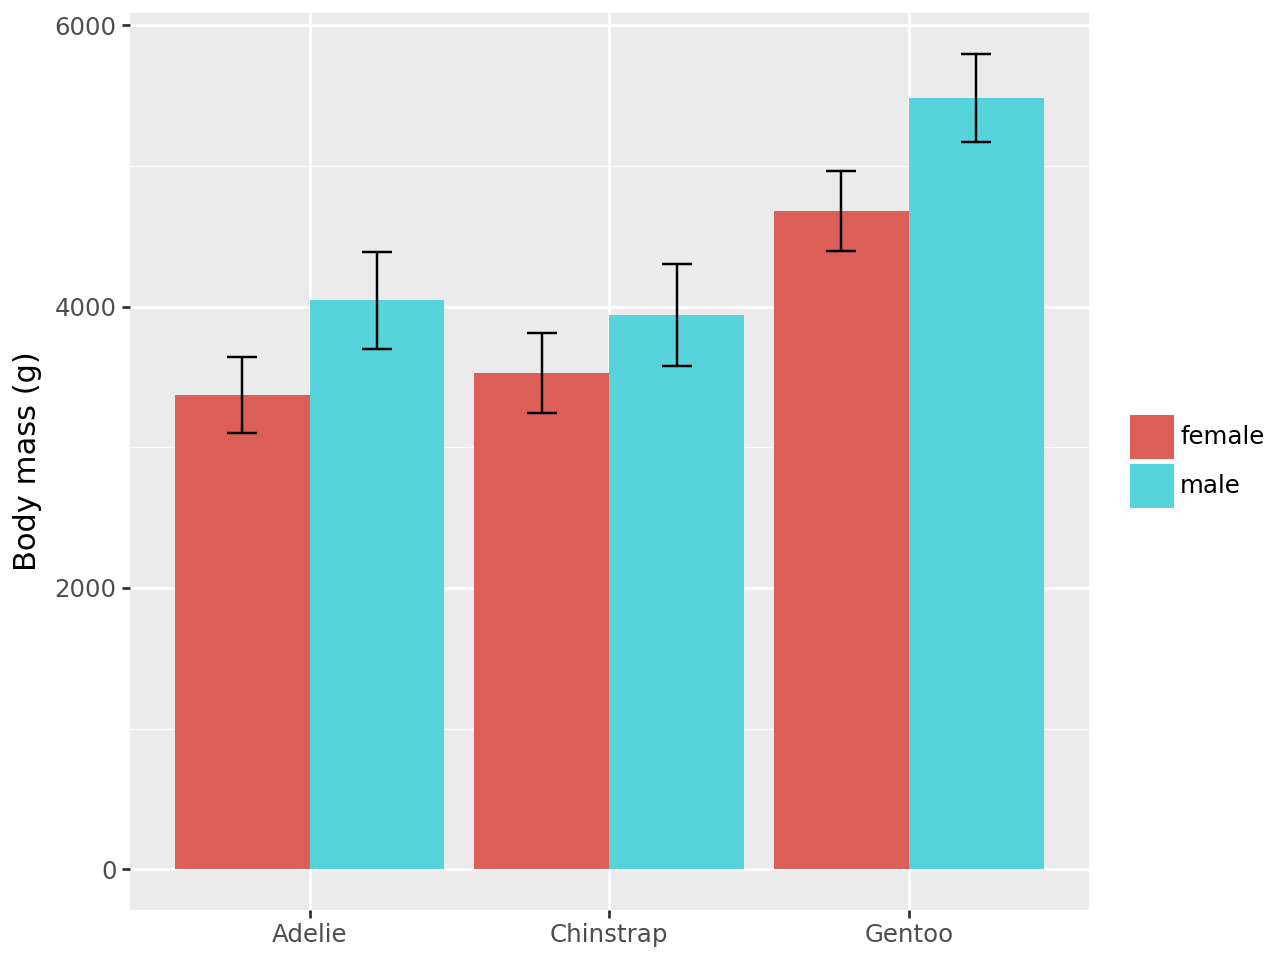

In [45]:
# import the plotnine pieces we’ll use
from plotnine import ggplot, aes, stat_summary, position_dodge, labs, theme, element_blank  

 # remove rows with missing values in the variables we plot
df_penguin = penguins.dropna(subset=["body_mass_g", "species", "sex"]) 

(
    ggplot(df_penguin, aes("species", "body_mass_g", fill="sex"))  # start a plot: x=species (categories), y=body_mass_g, color/fill bars by sex
    + stat_summary(  # compute summary statistics per (species, sex) group and draw a geometry
        geom="col",  # draw bars (columns)
        fun_y=np.mean,  # bar height = mean body mass in each group
        position=position_dodge(),  # place sex groups side-by-side within each species (dodged bars)
        #alpha=0.6  # make the bars slightly transparent (like seaborn's alpha=.6)
    )
    + stat_summary(  # add another summary layer, this time for error bars
        geom="errorbar",  # draw error bars
        fun_data="mean_sdl",  # errorbar limits = mean ± (mult * SD) for each group
        fun_args={"mult": 1},  # set mult=1 so we get mean ± 1 SD (matches seaborn errorbar="sd")
        position=position_dodge(width=0.9),  # dodge the error bars so they align with the dodged bars
        width=0.2  # width of the little horizontal caps at the ends of the error bars
    )
    + labs(x="", y="Body mass (g)", fill="")  # axis/legend labels: blank x label, y label text, and remove legend title
    + theme(legend_title=element_blank())  # also ensure the legend title is blank
)

---

**Try followings and reflect on**

- Explore some time how the `stat_summary()` function is used here 

- Look at the each code line explanation and explore how they work on a certain part of final visualization
---

### boxplot - Understanding the distributional behavior of numerical variable 

- Box plots are effective for visualizing the distribution of numerical data and identifying potential outliers.

- We'll compare the distribution of total bill amounts across different days.

[Explore the other parameters](https://seaborn.pydata.org/generated/seaborn.boxplot.html) such as; dropping x='day', adding `hue="sex"`, `fill=False`

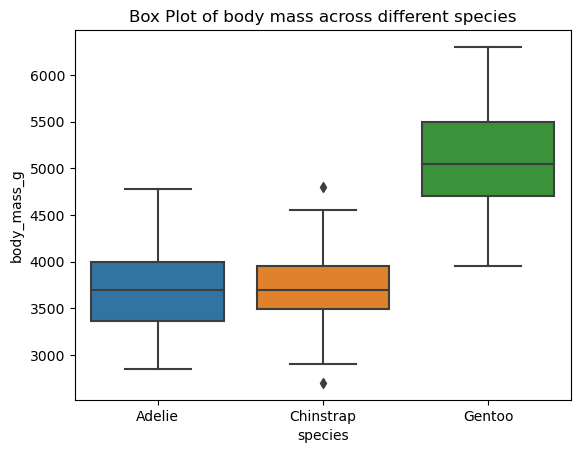

In [46]:
# EARLIER on WITH SEABORN

# Create a box plot
sns.boxplot(data=df_penguin, x='species', y="body_mass_g")
# Add a title
plt.title('Box Plot of body mass across different species')
# To display the plot clearly
plt.show()

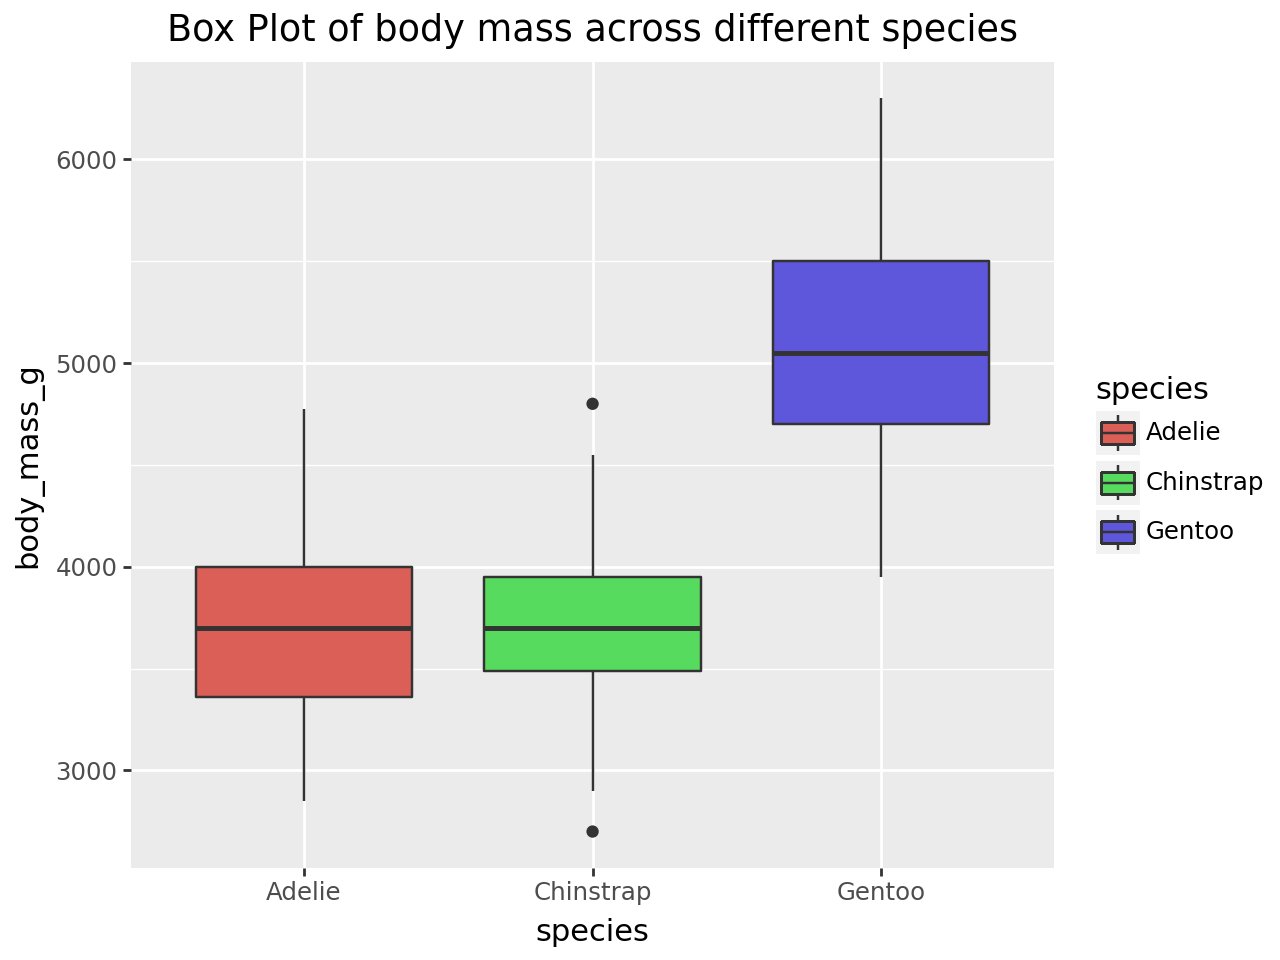

In [48]:
# NOW DOING WITH Plotnine in a different syntax

( # start a plot: x=species (categories), y=body_mass_g, color/fill bars by species
    ggplot(df_penguin, aes("species", "body_mass_g", fill="species"))  
    + geom_boxplot() # Type of geom for boxplot
    # axis/legend labels: change only the title but you can do more with related input parameters
    + labs(title = 'Box Plot of body mass across different species')  

)

**Try followings and reflect on**

- what happens if you change `fill="species"` to `color="species"`
- What about adding `+ geom_jitter()` as an additional layer after importing this function
- How about the alternatives to boxplot ? Try to get similar visualizations by using the followings; 
    - [violinplot](https://plotnine.org/reference/geom_violin.html#plotnine.geom_violin): A combination of boxplot and kernel density estimation.

Ask your further questions through a suitable channel for you, always happy to answer as long as I can do :)

### heatmap - overall relationship between numerical variables over correlation

- Plot rectangular data as a color-encoded matrix using the correlation information between numerical variables

- This is an Axes-level function and will draw the heatmap into the currently-active Axes if none is provided to the ax argument. 

[Explore the other parameters](https://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap) such as; `annot`, `cbar` or  `cmap='coolwarm'`

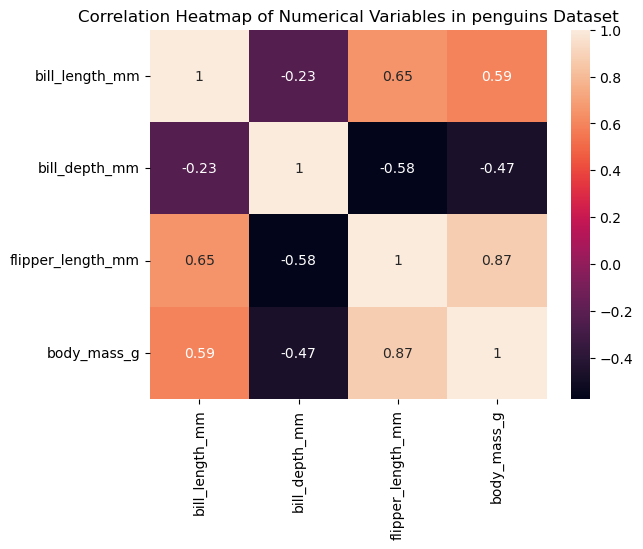

In [91]:
# Select only numerical columns without year 
numerical_penguins = df_penguin.select_dtypes(include='number').drop(columns=["year"])

# Create a heatmap of the numerical variables based on their correlation
sns.heatmap(numerical_penguins.corr(), annot=True)

# Add a title
plt.title('Correlation Heatmap of Numerical Variables in penguins Dataset')

# Display the plot
plt.show()

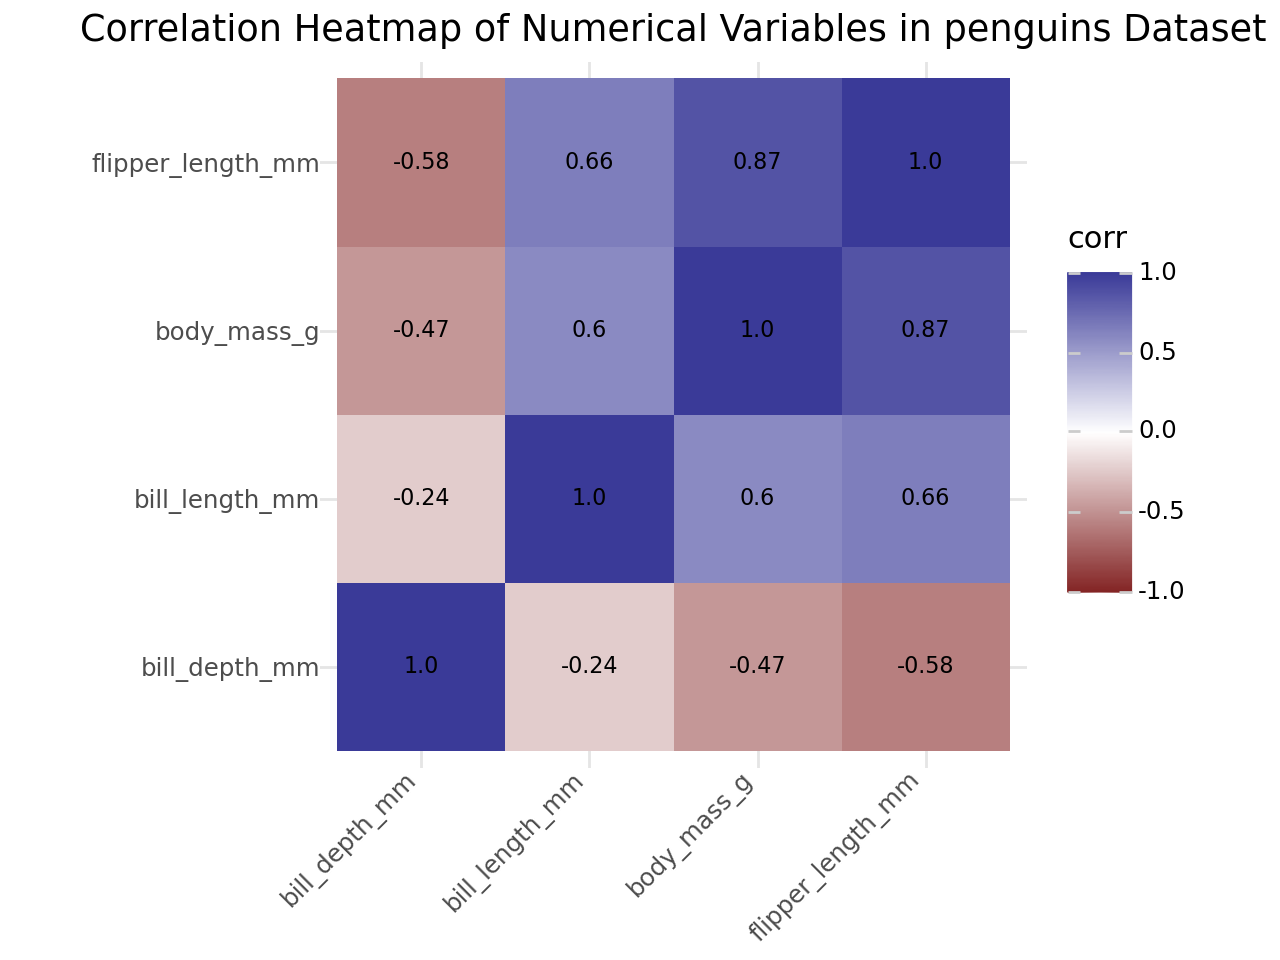

In [10]:
# 1) keep only numeric columns
numerical_penguins = df_penguin.select_dtypes(include="number").drop(columns=["year"])

# 2) correlation matrix (optionally handle missing values)
corr = numerical_penguins.corr()

# 3) reshape to long format for plotnine (var1, var2, corr_value)
corr_long = (
    corr.reset_index()
        .melt(id_vars="index", var_name="var2", value_name="corr")
        .rename(columns={"index": "var1"})
)

# 4) heatmap + annotations
(
    ggplot(corr_long, aes("var2", "var1", fill="corr"))
    + geom_tile()
    + geom_text(aes(label=corr_long["corr"].round(2)), size=8)  # annotate like seaborn's annot=True
    + scale_fill_gradient2(limits=(-1, 1))  # symmetric scale for correlations
    + coord_fixed()  # make tiles square-ish
    + labs(title="Correlation Heatmap of Numerical Variables in penguins Dataset",
           x="", y="", fill="corr")
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45, ha="right"))
)

### Setting and changing the theme or background 

Customizing the appearance of your Seaborn boxplots can enhance the clarity and aesthetics of your visualizations. Below are examples demonstrating how to set and change the theme or background of a boxplot using the tips dataset.

**1. `plotnine.theme`**

Base class for themes. In general, only complete themes should subclass this class.

There are 3 main top level theming elements:

- text - controls all the text elements in the figure.
- rect - controls all the rectangles in the figure.
- line - controls all the lines in the figure.

**2. Customizing themes**

We have some direct built in functions to add to our workflow to make our visualization in certain format 

- `theme_set(theme_void())`: We use theme_void as the base theme so that the modifications. we make in the code are transparent in the output


In [51]:
# Some list of colors that we can think about 
black = "#222222"
gray = "#666666"
red = "#FF3333"
green = "#66CC00"
blue = "#3333FF"
purple = "#9933FF"
orange = "#FF8000"
yellow = "#FFFF33"

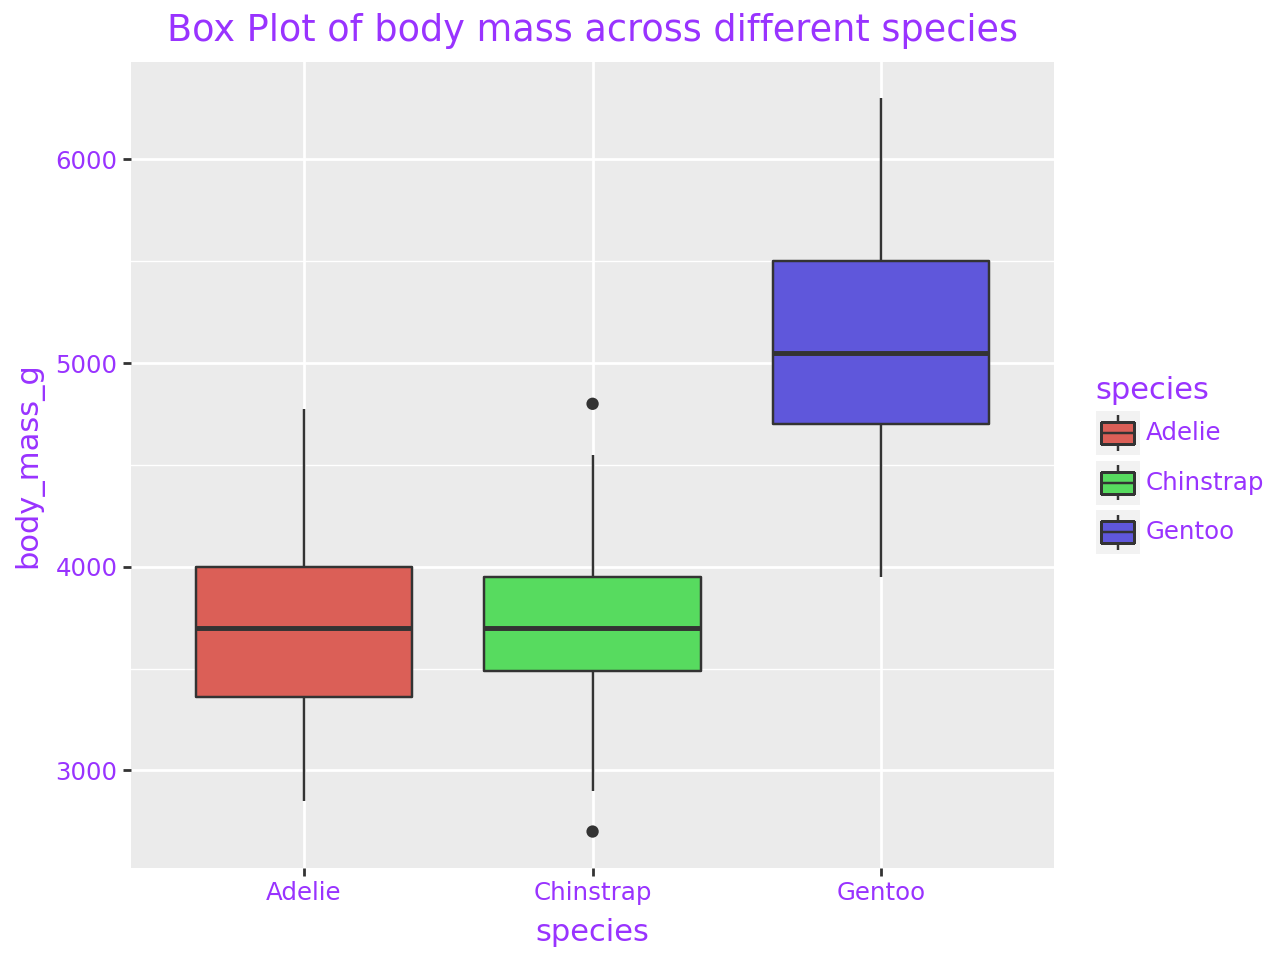

In [54]:
# NOW DOING WITH Plotnine in a different syntax
( # start a plot: x=species (categories), y=body_mass_g, color/fill bars by species
    ggplot(df_penguin, aes("species", "body_mass_g", fill="species"))  
    + geom_boxplot() # Type of geom for boxplot
    # axis/legend labels: blank x label, y label text, and remove legend title
    + labs(title = 'Box Plot of body mass across different species')
    + theme(text=element_text(color=purple))

)

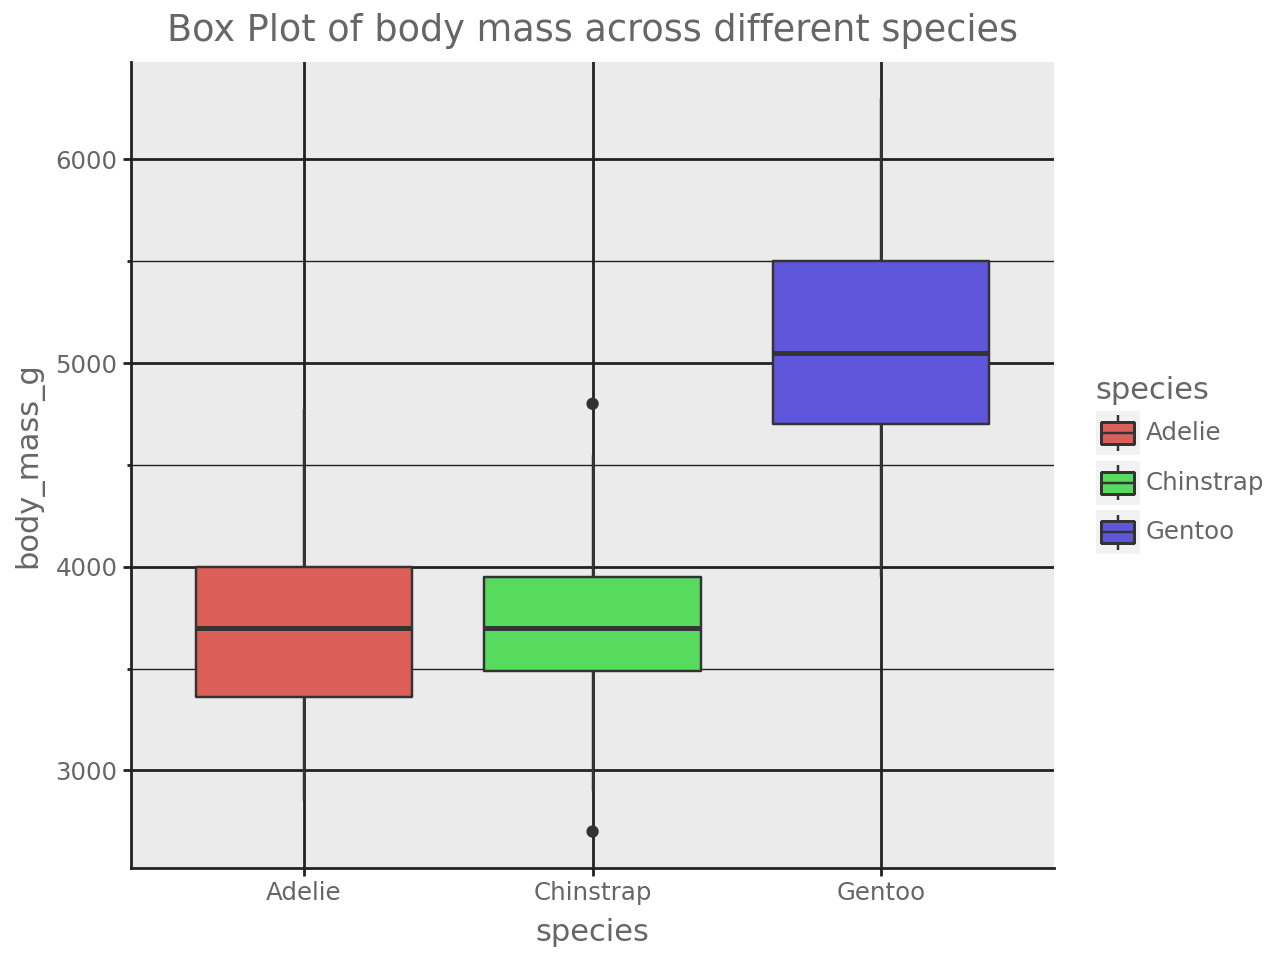

In [60]:
# NOW DOING WITH Plotnine in a different syntax
( # start a plot: x=species (categories), y=body_mass_g, color/fill bars by species
    ggplot(df_penguin, aes("species", "body_mass_g", fill="species"))  
    + geom_boxplot() # Type of geom for boxplot
    # axis/legend labels: blank x label, y label text, and remove legend title
    + labs(title = 'Box Plot of body mass across different species')
    + theme(text=element_text(color=gray))
    + theme(line=element_line(color=black))

)

/opt/conda/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 2 rows containing non-finite values.


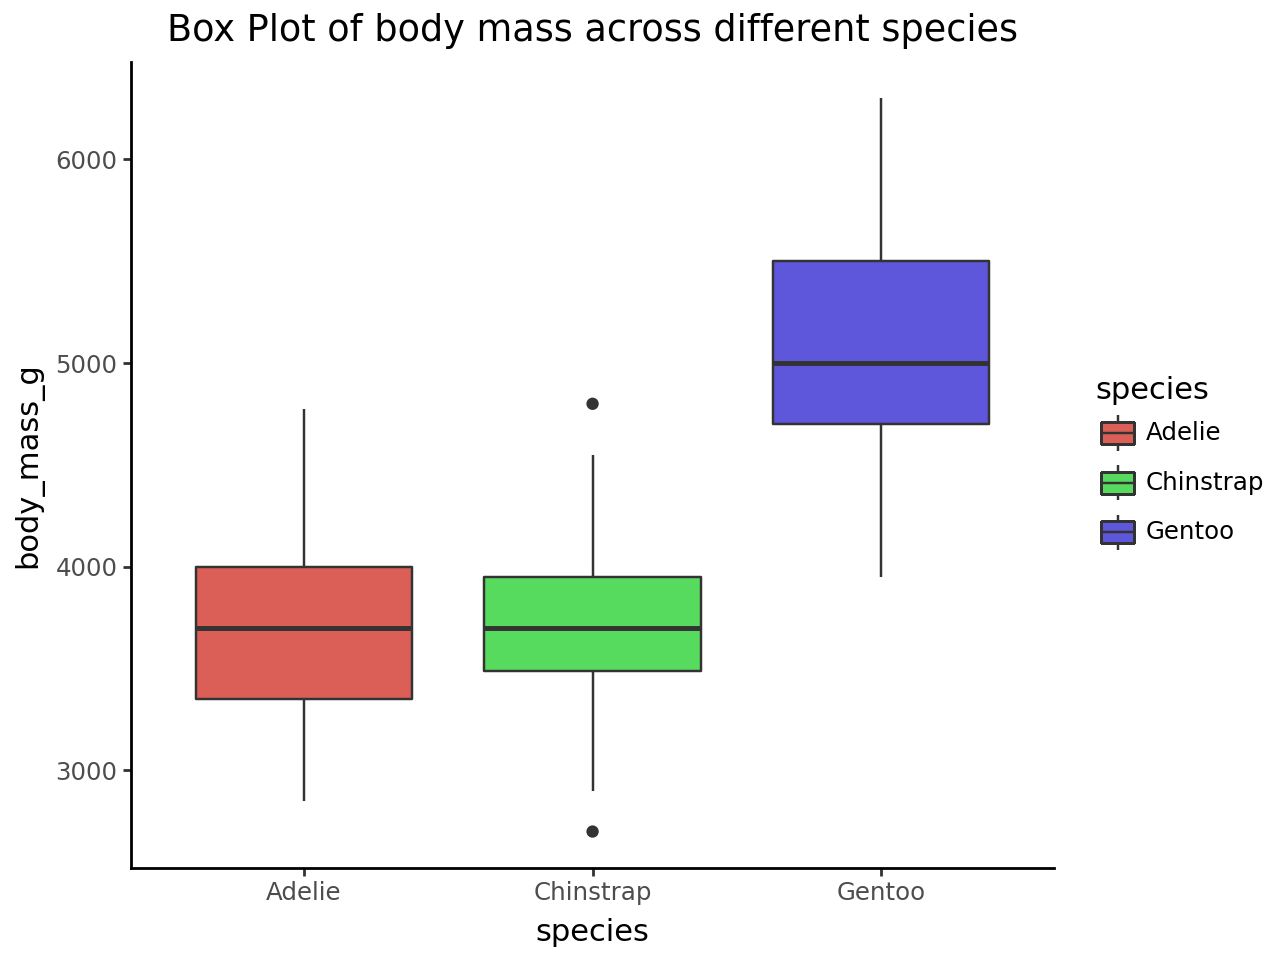

In [11]:
# Certain built in themes can be considered by their definition 

# Themes control the visual appearance of the non-data elements the plot.

( # start a plot: x=species (categories), y=body_mass_g, color/fill bars by species
    ggplot(df_penguin, aes("species", "body_mass_g", fill="species"))  
    + geom_boxplot() # Type of geom for boxplot
    # axis/legend labels: blank x label, y label text, and remove legend title
    + labs(title = 'Box Plot of body mass across different species')
    #+ theme(text=element_text(color=purple))
    #+ theme(line=element_line(color=black))
    + theme_classic()

)

### Saving the images to use for your portfolio or beyond

This part can be limited in plotnine and tricky compared to original ggplot2 package or seaborn options. 


One simple option given below with the save function

The other option is doing multiple figures to single pdf file. So it is better to think about creating individual images in good resolution and size, also with proper themes. Afterwards, taking snapshot seems like a useful shortcut for novice learners.

[Save multiple ggplot objects to a PDF file, one per page](https://plotnine.org/reference/save_as_pdf_pages.html#plotnine.save_as_pdf_pages)


In [13]:
p = ( # start a plot: x=species (categories), y=body_mass_g, color/fill bars by species
    ggplot(df_penguin, aes("species", "body_mass_g", fill="species"))  
    + geom_boxplot() # Type of geom for boxplot
    # axis/legend labels: blank x label, y label text, and remove legend title
    + labs(title = 'Box Plot of body mass across different species')
    #+ theme(text=element_text(color=purple))
    #+ theme(line=element_line(color=black))
    + theme_classic()

)
p.save("penguin_boxplot.png", dpi = 300) # think about adding width=__, height=__ with specific numbers here

/opt/conda/lib/python3.9/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 6.4 x 4.8 in image.
/opt/conda/lib/python3.9/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: penguin_boxplot.png
/opt/conda/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 2 rows containing non-finite values.


### Other plots and visualizations to explore and inspire from

- [Cara's penguins story on baking](https://www.cararthompson.com/talks/nhsr2022-level-up/)

- [Coal production since 1900: annotated area charts with plotnine](https://nrennie.rbind.io/2024-plotnine-contest/)

- [Weather Forecast](https://plotnine.org/gallery/weather-forecast.html)


## Next Step? - Altair your data : )

Altair library is a declarative statistical visualization library for Python. It allows you to create interactive and informative visualizations. 

For the main steps that we need to remember, we can follow the below step-by-step guidance all the time;

### Main Components of 

**Import Libraries**: Import necessary libraries such as Altair and Pandas to handle data and create visualizations.

**Prepare Your Data**: Load and prepare your data using Pandas, ensuring it's in a suitable format for visualization.

**Create a Base Chart**: Use [`alt.Chart()`](https://altair-viz.github.io/user_guide/generated/toplevel/altair.Chart.html) to define a base chart with your DataFrame as the starting point.

**Choose a Mark Type**: Select the type of visualization (e.g., bar, line, scatter) using the appropriate [`mark_*`](https://altair-viz.github.io/user_guide/marks/index.html) method. Such as; `mark_line()`, `mark_point()`, etc.

**Encode Data**: Map data fields to visual properties like axes, colors, and sizes using the [`encode()`](https://altair-viz.github.io/user_guide/encodings/index.html#encoding-data-types) method.
